In [1]:
import sys                                                                                                                                                                                                        
sys.path.insert(0, '/home/svu/e1498138/emri_search/work')                                                                                                                                                   
                                                                                                                                                                                                                    
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response                                                                                                                                                 
from loglike_timemax_noise import LogLike                                                                                                                                                                           
import numpy as np                                                                                                                                                                                                        
import cupy as cp

In [2]:
use_gpu=True                                                                                                                                       
T = 12/12        # years                 
dt = 5       # seconds

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 8.2
e0 = 0.4
xI0 = 1.0
dist = 9 # 9  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5                                                                                                                           
                                                                                                                                                                                                                                                                                                                                                    
                                        
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    
         

In [3]:
params=[m1,m2,a,p0,e0,xI0,dist,qS,phiS,qK,phiK,Phi_phi0,Phi_theta0,Phi_r0]

In [4]:
# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

In [5]:
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=True,tdi_gen=1)

In [6]:
# gwf_1yr = GravWaveAnalysis(T=1, dt=dt, use_gpu=True,tdi_gen=1)

In [7]:


loglike_obj= LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response,                                                                                                                                                                            
    gwf=gwf,                                                                                                                                                                                                      
    add_noise=True,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

[INFO] Added colored noise with seed=0
Delta_T for mode selection: 6311.629952709119 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Flattened modes: [(2, 0, -1),

In [8]:
loglike_obj.signal

array([[ 2.29037824e-21, -5.96831485e-21,  1.52055623e-20, ...,
         8.94321381e-21, -5.56764019e-21,  3.35656256e-21],
       [ 1.27927097e-21, -1.87985533e-21,  1.62884555e-21, ...,
        -1.40448937e-20,  8.05921996e-21, -9.80704172e-21],
       [-1.10100941e-21,  1.19570151e-20, -1.61856432e-20, ...,
        -2.16018325e-21, -7.88098485e-21,  7.26155734e-21]])

In [9]:
%%time
#loglike at true param
logl_true=loglike_obj(params)
print(logl_true)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=8.658, rho=2.942
  Mode 1: <hf|hf>_timemax=44.36, rho=6.66
  Mode 2: <hf|hf>_timemax=119.4, rho=10.93
  Mode 3: <hf|hf>_timemax=80.09, rho=8.949
  Mode 4: <hf|hf>_timemax=31.26, rho=5.591
  Mode 5: <hf|hf>_timemax=9.259, rho=3.043
  Mode 6: <hf|hf>_timemax=2.339, rho=1.529
rho_m: [ 2.94247764  6.6602001  10.92850321  8.94936781  5.59070851  3.04284451
  1.52924069]
Dominant mode index: 2, rho: 10.93
beta=0.02239, rho_dom_M=10.93, rho_tot=18.25
X_scalar (time-maximized): 18.06
Time-maximized Log-likelihood: 16.9381
16.938118212494693
CPU times: user 448 ms, sys: 17.3 ms, total: 465 ms
Wall time: 518 ms


In [10]:
params_perturbed = list(params)                                                                                                                                                                                     
params_perturbed[0] *= 1.01                                                                                                                                                                                         
logl_perturbed = loglike_obj(params_perturbed)                                                                                                                                                                               
print(logl_perturbed)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=7.948, rho=2.819
  Mode 1: <hf|hf>_timemax=40.64, rho=6.375
  Mode 2: <hf|hf>_timemax=114.3, rho=10.69
  Mode 3: <hf|hf>_timemax=78.73, rho=8.873
  Mode 4: <hf|hf>_timemax=31.23, rho=5.588
  Mode 5: <hf|hf>_timemax=9.324, rho=3.054
  Mode 6: <hf|hf>_timemax=2.367, rho=1.538
rho_m: [ 2.81914747  6.37514672 10.69245651  8.87312163  5.58794703  3.05352801
  1.53842666]
Dominant mode index: 2, rho: 10.69
beta=0.02294, rho_dom_M=10.69, rho_tot=17.91
X_scalar (time-maximized): 5.256
Time-maximized Log-likelihood: 1.23324
1.2332415946012172


In [11]:

def logden_tm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_obj(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

In [12]:
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0])


In [13]:
# Sanity check at true params
print(logden_tm(param_true))

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=8.658, rho=2.942
  Mode 1: <hf|hf>_timemax=44.36, rho=6.66
  Mode 2: <hf|hf>_timemax=119.4, rho=10.93
  Mode 3: <hf|hf>_timemax=80.09, rho=8.949
  Mode 4: <hf|hf>_timemax=31.26, rho=5.591
  Mode 5: <hf|hf>_timemax=9.259, rho=3.043
  Mode 6: <hf|hf>_timemax=2.339, rho=1.529
rho_m: [ 2.94247764  6.6602001  10.92850321  8.94936781  5.59070851  3.04284451
  1.52924069]
Dominant mode index: 2, rho: 10.93
beta=0.02239, rho_dom_M=10.93, rho_tot=18.25
X_scalar (time-maximized): 18.06
Time-maximized Log-likelihood: 16.9381
16.938118212494693


In [ ]:
# # Sweep over logm2
# param_idx = 1  # logm2
# # param_secondary = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])

# param_range = np.sort(np.append(np.linspace(0.99, 1.01, 200), param_true[param_idx]))

# f_stats_tm   = np.zeros(len(param_range))
# # f_stats_pm   = np.zeros(len(param_range))
# # f_stats_pure = np.zeros(len(param_range))
# # f_stats_tmX = np.zeros(len(param_range))
# # X_pure = np.zeros(len(param_range))
# X_tm = np.zeros(len(param_range))
# X_tpm = np.zeros(len(param_range))
# X_sc = np.zeros(len(param_range))


# for i, val in enumerate(param_range):

#     p = param_true.copy()
#     p[param_idx] = val
#     # f_stats_tm[i]   = logden_tm(p)
#     # f_stats_pm[i]   = logden_pm(p)
#     # f_stats_pure[i] = logden_pure(p)
#     # f_stats_tmX[i] = logden_tmX(p)

#     # X only (no chi_sq)
#     logm1, logm2, a_i, p0_i, e0_i = p
#     h = gwf.xp.array(waveform_response(
#         10**logm1, 10**logm2, a_i, p0_i, e0_i,
#         xI0, dist, qS, phiS, qK, phiK,
#         Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
#     ))
#     h_fft_r = gwf.freq_wave(h)
#     rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
#     # X_pure[i] = float(gwf.inner(loglike_obj.signal_fft, h_fft_r, return_complex=False)) / rho_h
#     # X_tm[i] = float(gwf.inner_timemax(loglike_obj.signal, h,phasemax=False)) / rho_h
#     # X_tpm[i] = float(gwf.inner_timemax(loglike_obj.signal, h,phasemax=True)) / rho_h
#     X_sc[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=12))

In [14]:
print('Initializing loglike_pure...')
params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

import loglike_pure_noise
loglike_p = loglike_pure_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

Initializing loglike_pure...


In [15]:
def logden_pure(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_p(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

In [16]:
# Sweep over logm2
param_idx = 1  # logm2
# param_secondary = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])

param_range = np.sort(np.append(np.linspace(0.975, 1.025, 100), param_true[param_idx]))

f_stats_tm   = np.zeros(len(param_range))
# f_stats_pm   = np.zeros(len(param_range))
f_stats_pure = np.zeros(len(param_range))
# f_stats_tmX = np.zeros(len(param_range))
# X_pure = np.zeros(len(param_range))
X_tm = np.zeros(len(param_range))
X_tpm = np.zeros(len(param_range))
Sfour = np.zeros(len(param_range))
Ssix = np.zeros(len(param_range))
Stwelve = np.zeros(len(param_range))
Ssixteen = np.zeros(len(param_range))
Sp= np.zeros(len(param_range))

for i, val in enumerate(param_range):

    p = param_true.copy()
    p[param_idx] = val
    f_stats_tm[i]   = logden_tm(p)
    # f_stats_pm[i]   = logden_pm(p)
    # f_stats_pure[i] = logden_pure(p)
    # f_stats_tmX[i] = logden_tmX(p)

    # X only (no chi_sq)
    logm1, logm2, a_i, p0_i, e0_i = p
    h = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    ))
    h_fft_r = gwf.freq_wave(h)
    rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
    # X_pure[i] = float(gwf.inner(loglike_obj.signal_fft, h_fft_r, return_complex=False)) / rho_h
    # X_tm[i] = float(gwf.inner_timemax(loglike_obj.signal, h)) / rho_h
    # X_tpm[i] = float(gwf.inner_timemax(loglike_obj.signal, h)) / rho_h
    # Sfour[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=4))
    # Ssix[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=6))
    Stwelve[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=12))
    # Ssixteen[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=16))
    Sp[i] = float(gwf.SNR_semicoherent_nomax(loglike_obj.signal, h, N_seg=12))


Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=6.755, rho=2.599
  Mode 1: <hf|hf>_timemax=33.56, rho=5.793
  Mode 2: <hf|hf>_timemax=99.8, rho=9.99
  Mode 3: <hf|hf>_timemax=70.78, rho=8.413
  Mode 4: <hf|hf>_timemax=28.52, rho=5.34
  Mode 5: <hf|hf>_timemax=8.593, rho=2.931
  Mode 6: <hf|hf>_timemax=2.19, rho=1.48
rho_m: [2.59909976 5.79313329 9.98986627 8.41313273 5.3402374  2.9314443
 1.48002346]
Dominant mode index: 2, rho: 9.99
beta=0.02528, rho_dom_M=9.99, rho_tot=16.79
X_scalar (time-maximized): 5.109
Time-maximized Log-likelihood: 1.22821
Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=6.788, rho=2.605
  Mode 1: <hf|hf>_timemax=33.73, rho=5.808
  Mode 2: <hf|hf>_timemax=100.1, rho=10.01
  Mode 3: <hf|hf>_timemax=70.94, rho=8.422
  Mode 4: <hf|hf>_timemax=28.57, rho=5.345
  Mode 5: <hf|hf>_timemax=8.611, rho=2.934
  Mode 6: <hf|hf>_timemax=2.195, rho=1.482
rho_m: [ 2.60532271  5.80804004 10.0066273   8.42241069  5.34493287  2.93436679
  1.4815568

In [17]:
import matplotlib.pyplot as plt

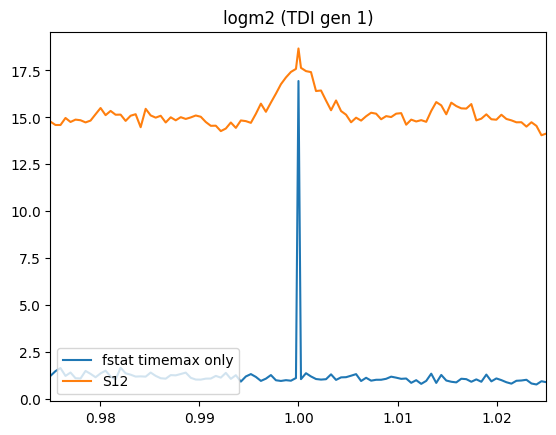

In [22]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax only')
# plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
# plt.plot(param_range, f_stats_pure, label='fstat pure')
# plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
# plt.plot(param_range, X_pure, label='X pure')
# plt.plot(param_range, X_tm, label='X timemax')
# plt.plot(param_range, X_tpm, label='X timemax +phasemax')
# plt.plot(param_range, Sfour, label='S4')
# plt.plot(param_range, Ssix, label='S6')
plt.plot(param_range, Stwelve, label='S12')
# plt.plot(param_range, Ssixteen, label='S16')
# plt.plot(param_range, Sp, label='S12 no timemax')

plt.xlim(0.975, 1.025)
plt.title('logm2 (TDI gen 1)')
plt.legend(loc='lower left')
plt.savefig('logden.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_sc_line, '-', 
            color='blue', alpha=0.5, linewidth=2, label='semicoherent')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [ ]:
# Generate trajectory to get fundamental frequencies
print("Computing fundamental frequencies...")
from few.trajectory.inspiral import EMRIInspiral
from few.utils.constants import YRSID_SI

N_traj = 5000
delta_T = T*YRSID_SI/5000
traj_gen = EMRIInspiral(func='KerrEccEqFlux')
t_arr, p_arr, e_arr, x_arr, Phi_phi_arr, Phi_theta_arr, Phi_r_arr = traj_gen(
    m1, m2, a, p0, e0, xI0, T=T, dt=dt, upsample=True,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0
)

In [ ]:
from few.utils.utility import get_p_at_t

get_p_at_t(traj_module=traj_gen, t_out=1, traj_args=[m1, m2, a, e0, xI0])
